In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
dataset_path = os.path.join("archive", "Car-Bike-Dataset")

In [4]:
classes = ['Bike', 'Car']

In [5]:
for cls in classes:
    folder = os.path.join(dataset_path, cls)
    files = os.listdir(folder)
    print(f"{cls}: {len(files)} pictures")

Bike: 2000 pictures
Car: 2000 pictures


In [6]:
IMG_SIZE = 64
X = []  
y = []
for label, cls in enumerate(classes):
    folder = os.path.join(dataset_path, cls)
    files = os.listdir(folder)
    
    for file in files:
        img_path = os.path.join(folder, file)
        try:
            img = Image.open(img_path).convert('L')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img_array = np.array(img).flatten()
            X.append(img_array)
            y.append(label)
        except:
            pass
X = np.array(X)
y = np.array(y)

print(f"X.shape: {X.shape}")
print(f"y.shape: {y.shape}")




X.shape: (4000, 4096)
y.shape: (4000,)


In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"train: {X_train.shape}")
print(f"test: {X_test.shape}")

train: (3200, 4096)
test: (800, 4096)


In [8]:

kernels = [
    {'kernel': 'linear', 'C': 0.1},
    {'kernel': 'linear', 'C': 1},
    {'kernel': 'linear', 'C': 10},
    {'kernel': 'rbf', 'C': 1, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 1, 'gamma': 0.001},
    {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 10, 'gamma': 0.001},
]

results = []
models = {}

for params in kernels:
    print(f"Training: {params} ...")
    start = time.time()
    model = SVC(**params)
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    key = str(params)
    models[key] = model
    results.append({**params, 'train_acc': train_acc, 'test_acc': test_acc})
    print(f"train: {train_acc:.3f} | test: {test_acc:.3f} | Time: {elapsed:.1f}s")
    print("-" * 50)

best = max(results, key=lambda x: x['test_acc'])
print(f"\nBest model: kernel={best['kernel']}, C={best['C']}, test_acc={best['test_acc']:.3f}")

Training: {'kernel': 'linear', 'C': 0.1} ...
train: 1.000 | test: 0.724 | Time: 113.1s
--------------------------------------------------
Training: {'kernel': 'linear', 'C': 1} ...
train: 1.000 | test: 0.723 | Time: 181.1s
--------------------------------------------------
Training: {'kernel': 'linear', 'C': 10} ...
train: 1.000 | test: 0.723 | Time: 201.9s
--------------------------------------------------
Training: {'kernel': 'rbf', 'C': 1, 'gamma': 'scale'} ...
train: 0.933 | test: 0.830 | Time: 217.7s
--------------------------------------------------
Training: {'kernel': 'rbf', 'C': 1, 'gamma': 0.001} ...
train: 0.997 | test: 0.829 | Time: 184.6s
--------------------------------------------------
Training: {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'} ...
train: 1.000 | test: 0.835 | Time: 192.8s
--------------------------------------------------
Training: {'kernel': 'rbf', 'C': 10, 'gamma': 0.001} ...
train: 1.000 | test: 0.836 | Time: 203.1s
--------------------------------------

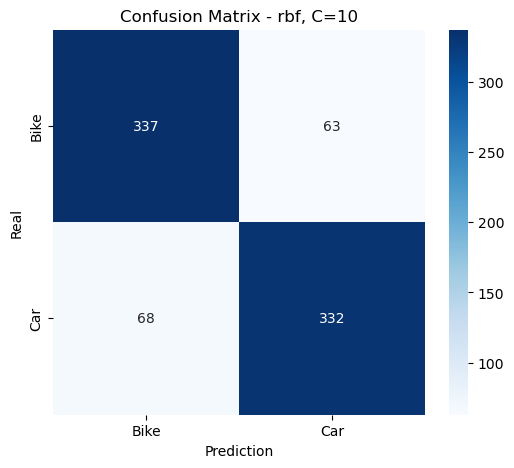

              precision    recall  f1-score   support

        Bike       0.83      0.84      0.84       400
         Car       0.84      0.83      0.84       400

    accuracy                           0.84       800
   macro avg       0.84      0.84      0.84       800
weighted avg       0.84      0.84      0.84       800



In [9]:

best = max(results, key=lambda x: x['test_acc'])
best_model = models[str({k: v for k, v in best.items() if k not in ['train_acc', 'test_acc']})]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bike','Car'],
            yticklabels=['Bike','Car'])
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title(f"Confusion Matrix - {best['kernel']}, C={best['C']}")
plt.show()

print(classification_report(y_test, y_pred, target_names=['Bike','Car']))

In [10]:
print("َAnalysis of Overfitting:\n")
for r in results:
    diff = r['train_acc'] - r['test_acc']
    kernel = r['kernel']
    C = r['C']
    gamma = r.get('gamma', '-')
    print(f"kernel={kernel}, C={C}, gamma={gamma}")
    print(f"  train={r['train_acc']:.3f} | test={r['test_acc']:.3f} | Difference={diff:.3f}")
    if diff > 0.05:
        print(f"Overfit")
    else:
        print(f"Balanced")
    print()

َAnalysis of Overfitting:

kernel=linear, C=0.1, gamma=-
  train=1.000 | test=0.724 | Difference=0.276
Overfit

kernel=linear, C=1, gamma=-
  train=1.000 | test=0.723 | Difference=0.277
Overfit

kernel=linear, C=10, gamma=-
  train=1.000 | test=0.723 | Difference=0.277
Overfit

kernel=rbf, C=1, gamma=scale
  train=0.933 | test=0.830 | Difference=0.103
Overfit

kernel=rbf, C=1, gamma=0.001
  train=0.997 | test=0.829 | Difference=0.168
Overfit

kernel=rbf, C=10, gamma=scale
  train=1.000 | test=0.835 | Difference=0.165
Overfit

kernel=rbf, C=10, gamma=0.001
  train=1.000 | test=0.836 | Difference=0.164
Overfit



In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn_results = []

for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, knn.predict(X_train))
    test_acc = accuracy_score(y_test, knn.predict(X_test))
    
    knn_results.append({'k': k, 'train_acc': train_acc, 'test_acc': test_acc})
    print(f"KNN (k={k}): train={train_acc:.3f} | test={test_acc:.3f}")

best_knn = max(knn_results, key=lambda x: x['test_acc'])
print(f"\nBest KNN: k={best_knn['k']}, test_acc={best_knn['test_acc']:.3f}")
print(f"Best SVM: kernel={best['kernel']}, C={best['C']}, test_acc={best['test_acc']:.3f}")

if best_knn['test_acc'] > best['test_acc']:
    print("\nKNN performed better than SVM!")
else:
    print("\nSVM performed better than KNN!")

KNN (k=3): train=0.872 | test=0.715
KNN (k=5): train=0.837 | test=0.713
KNN (k=7): train=0.827 | test=0.708

Best KNN: k=3, test_acc=0.715
Best SVM: kernel=rbf, C=10, test_acc=0.836

SVM performed better than KNN!
